In [1]:
import pandas as pd
import numpy as np
import os, glob, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d, CubicSpline

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

TRAIN_DIR = 'data/raw/train'
TEST_DIR  = 'data/raw/test'
SEED      = 42
np.random.seed(SEED)

hw_files = sorted(glob.glob(f'{TRAIN_DIR}/*__horizontal_well.csv'))
print(f'Total train wells: {len(hw_files)}')
print('Setup done!')

Total train wells: 773
Setup done!


In [2]:
sample_wells = hw_files[:5]
stats = []
for fp in sample_wells:
    well_id = os.path.basename(fp).replace('__horizontal_well.csv', '')
    df = pd.read_csv(fp, usecols=['MD','GR','TVT_input','TVT'])
    n_total = len(df)
    n_known = df['TVT_input'].notna().sum()
    stats.append({
        'well_id'     : well_id[:8],
        'total_rows'  : n_total,
        'known_TVT'   : n_known,
        'null_TVT'    : n_total - n_known,
        'known_pct'   : round(n_known / n_total * 100, 1),
        'MD_range'    : round(df['MD'].max() - df['MD'].min(), 1),
        'GR_mean'     : round(df['GR'].mean(), 1),
    })

pd.DataFrame(stats)

,well_id,total_rows,known_TVT,null_TVT,known_pct,MD_range,GR_mean
0,000d7d20,5278,1442,3836,27.3,5277.0,94.4
1,00bbac68,7559,1545,6014,20.4,7558.0,88.3
2,00e12e8b,6384,2083,4301,32.6,6383.0,53.6
3,015fe0d2,5950,1654,4296,27.8,5949.0,88.0
4,01869cd4,6850,1293,5557,18.9,6849.0,87.0


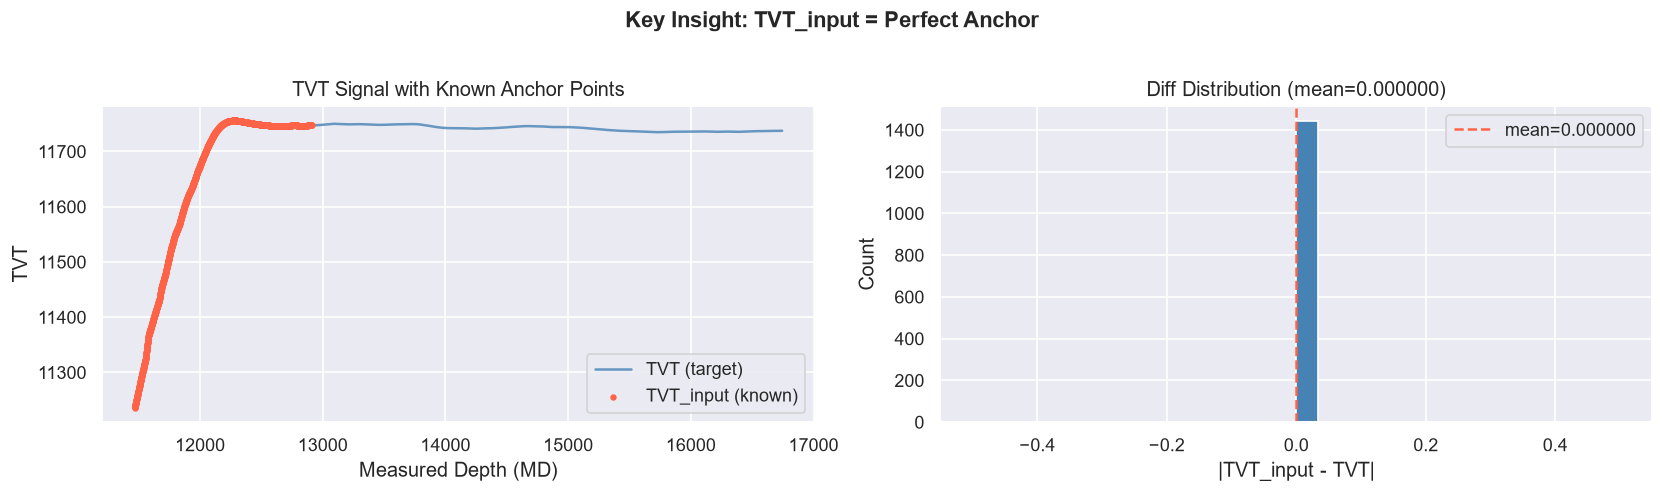

Max diff: 0.00000000


In [3]:
df = pd.read_csv(hw_files[0], usecols=['MD','TVT_input','TVT'])
known = df[df['TVT_input'].notna()].copy()
diff = (known['TVT_input'] - known['TVT']).abs()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(df['MD'], df['TVT'], color='steelblue', lw=1.5, label='TVT (target)', alpha=0.8)
ax.scatter(known['MD'], known['TVT_input'], color='tomato', s=8, label='TVT_input (known)', zorder=5)
ax.set_xlabel('Measured Depth (MD)')
ax.set_ylabel('TVT')
ax.set_title('TVT Signal with Known Anchor Points')
ax.legend()

ax = axes[1]
ax.hist(diff, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('|TVT_input - TVT|')
ax.set_ylabel('Count')
ax.axvline(diff.mean(), color='tomato', linestyle='--', label=f'mean={diff.mean():.6f}')
ax.set_title(f'Diff Distribution (mean={diff.mean():.6f})')
ax.legend()

plt.suptitle('Key Insight: TVT_input = Perfect Anchor', fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/01_tvt_anchor_insight.png', bbox_inches='tight')
plt.show()
print(f'Max diff: {diff.max():.8f}')

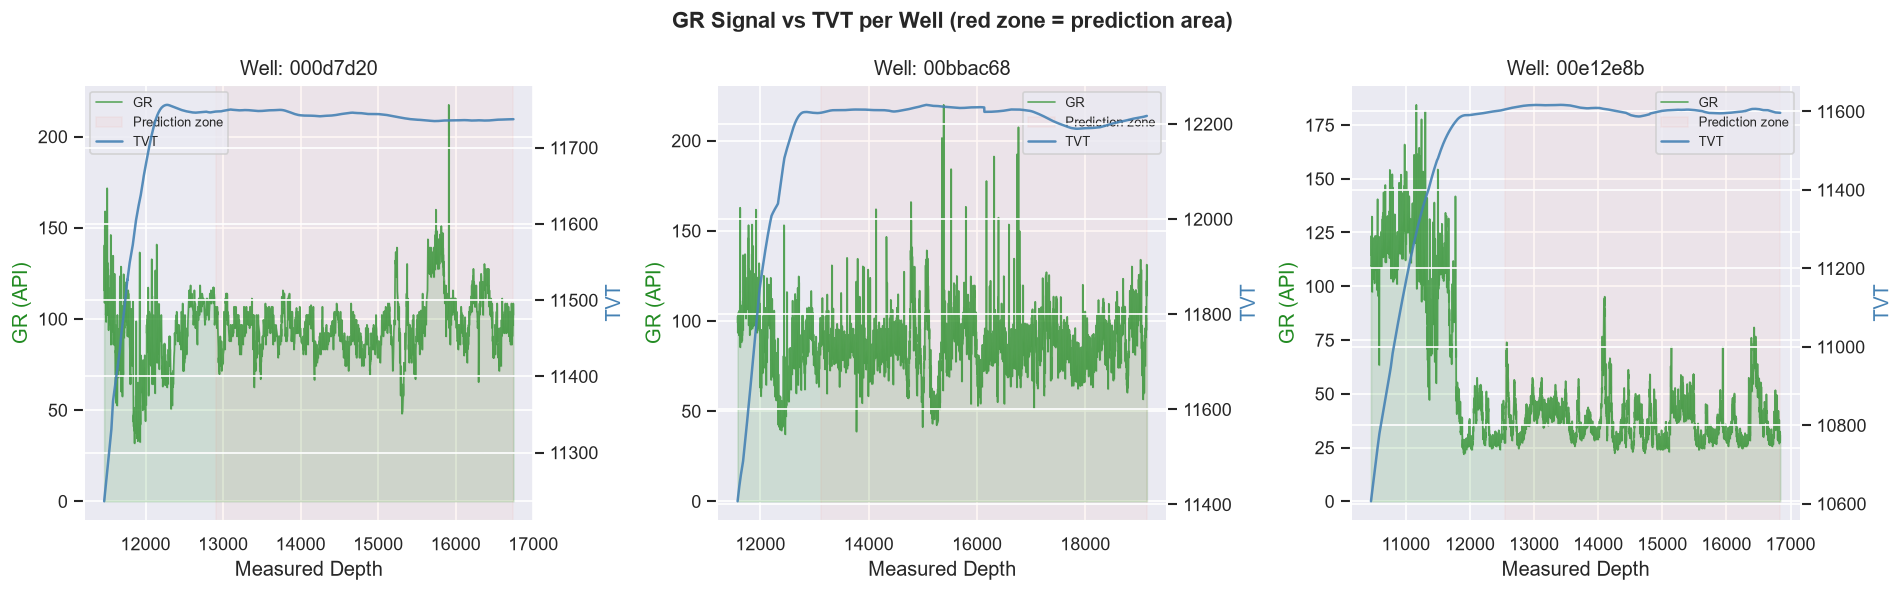

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, fp in enumerate(hw_files[:3]):
    well_id = os.path.basename(fp).replace('__horizontal_well.csv', '')[:8]
    df = pd.read_csv(fp, usecols=['MD','GR','TVT_input','TVT'])
    gr = df['GR'].interpolate('linear').bfill().ffill()

    ax = axes[i]
    ax2 = ax.twinx()

    ax.plot(df['MD'], gr, color='forestgreen', lw=1, alpha=0.7, label='GR')
    ax.fill_between(df['MD'], gr, alpha=0.15, color='forestgreen')
    ax2.plot(df['MD'], df['TVT'], color='steelblue', lw=1.5, alpha=0.9, label='TVT')

    null_mask = df['TVT_input'].isna()
    ax.axvspan(df.loc[null_mask, 'MD'].min(), df.loc[null_mask, 'MD'].max(),
               alpha=0.05, color='tomato', label='Prediction zone')

    ax.set_xlabel('Measured Depth')
    ax.set_ylabel('GR (API)', color='forestgreen')
    ax2.set_ylabel('TVT', color='steelblue')
    ax.set_title(f'Well: {well_id}')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('GR Signal vs TVT per Well (red zone = prediction area)', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_gr_tvt_visualization.png', bbox_inches='tight')
plt.show()

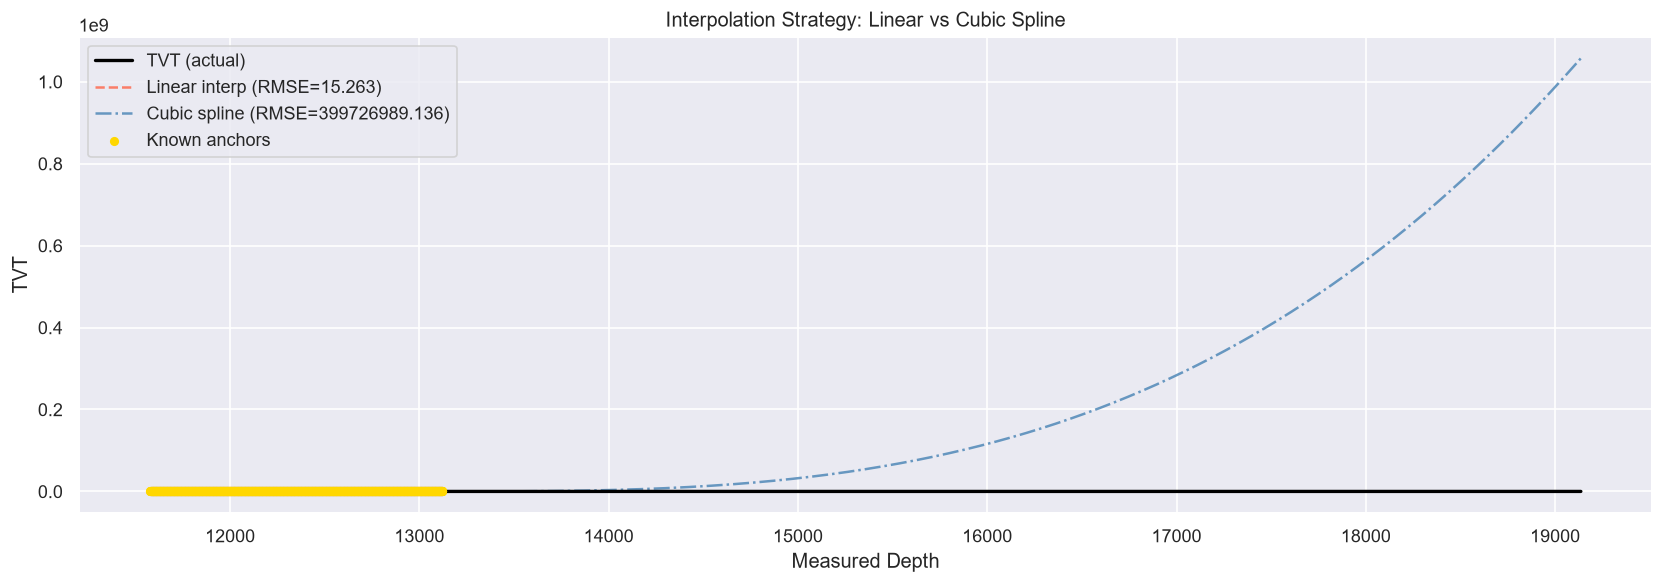

Linear RMSE : 15.2631
Cubic RMSE  : 399726989.1360


In [5]:
df = pd.read_csv(hw_files[1], usecols=['MD','TVT_input','TVT'])
known_mask = df['TVT_input'].notna()
known_idx  = np.where(known_mask)[0]
all_idx    = np.arange(len(df))

linear_interp = df['TVT_input'].interpolate('linear').bfill().ffill().values

cs = CubicSpline(known_idx, df['TVT_input'].iloc[known_idx].values, extrapolate=True)
cubic_interp = cs(all_idx)

null_mask = ~known_mask
rmse_linear = np.sqrt(np.mean((df.loc[null_mask, 'TVT'].values - linear_interp[null_mask])**2))
rmse_cubic  = np.sqrt(np.mean((df.loc[null_mask, 'TVT'].values - cubic_interp[null_mask])**2))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['MD'], df['TVT'], color='black', lw=2, label='TVT (actual)', zorder=5)
ax.plot(df['MD'], linear_interp, color='tomato', lw=1.5, linestyle='--',
        label=f'Linear interp (RMSE={rmse_linear:.3f})', alpha=0.8)
ax.plot(df['MD'], cubic_interp, color='steelblue', lw=1.5, linestyle='-.',
        label=f'Cubic spline (RMSE={rmse_cubic:.3f})', alpha=0.8)
ax.scatter(df.loc[known_mask, 'MD'], df.loc[known_mask, 'TVT_input'],
           color='gold', s=20, zorder=6, label='Known anchors')
ax.set_xlabel('Measured Depth')
ax.set_ylabel('TVT')
ax.set_title('Interpolation Strategy: Linear vs Cubic Spline')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/03_interpolation_comparison.png', bbox_inches='tight')
plt.show()
print(f'Linear RMSE : {rmse_linear:.4f}')
print(f'Cubic RMSE  : {rmse_cubic:.4f}')

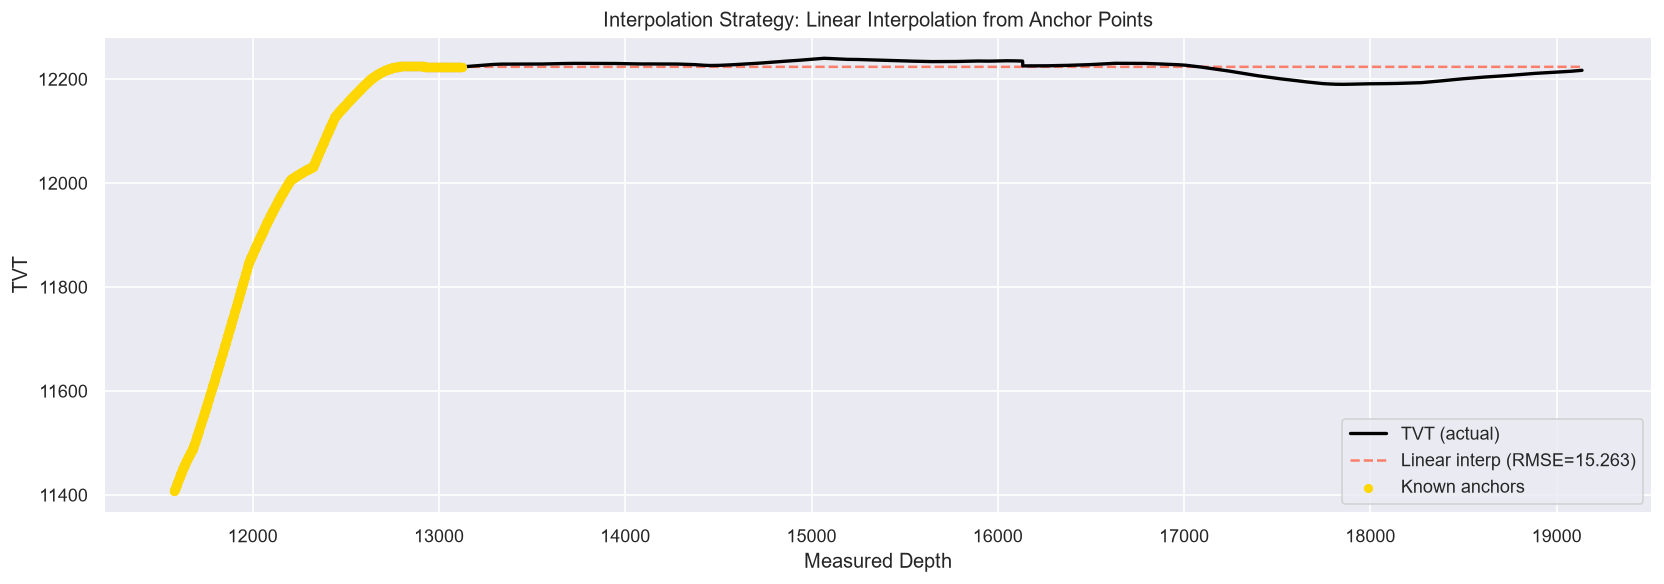

Linear RMSE : 15.2631
Insight: Cubic spline tidak stabil (RMSE=399726989) karena anchor points sparse
Strategy: Linear interp sebagai feature, LightGBM yang handle non-linearity


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['MD'], df['TVT'], color='black', lw=2, label='TVT (actual)', zorder=5)
ax.plot(df['MD'], linear_interp, color='tomato', lw=1.5, linestyle='--',
        label=f'Linear interp (RMSE={rmse_linear:.3f})', alpha=0.8)
ax.scatter(df.loc[known_mask, 'MD'], df.loc[known_mask, 'TVT_input'],
           color='gold', s=20, zorder=6, label='Known anchors')
ax.set_xlabel('Measured Depth')
ax.set_ylabel('TVT')
ax.set_title('Interpolation Strategy: Linear Interpolation from Anchor Points')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/03_interpolation_comparison.png', bbox_inches='tight')
plt.show()
print(f'Linear RMSE : {rmse_linear:.4f}')
print(f'Insight: Cubic spline tidak stabil (RMSE={rmse_cubic:.0f}) karena anchor points sparse')
print(f'Strategy: Linear interp sebagai feature, LightGBM yang handle non-linearity')

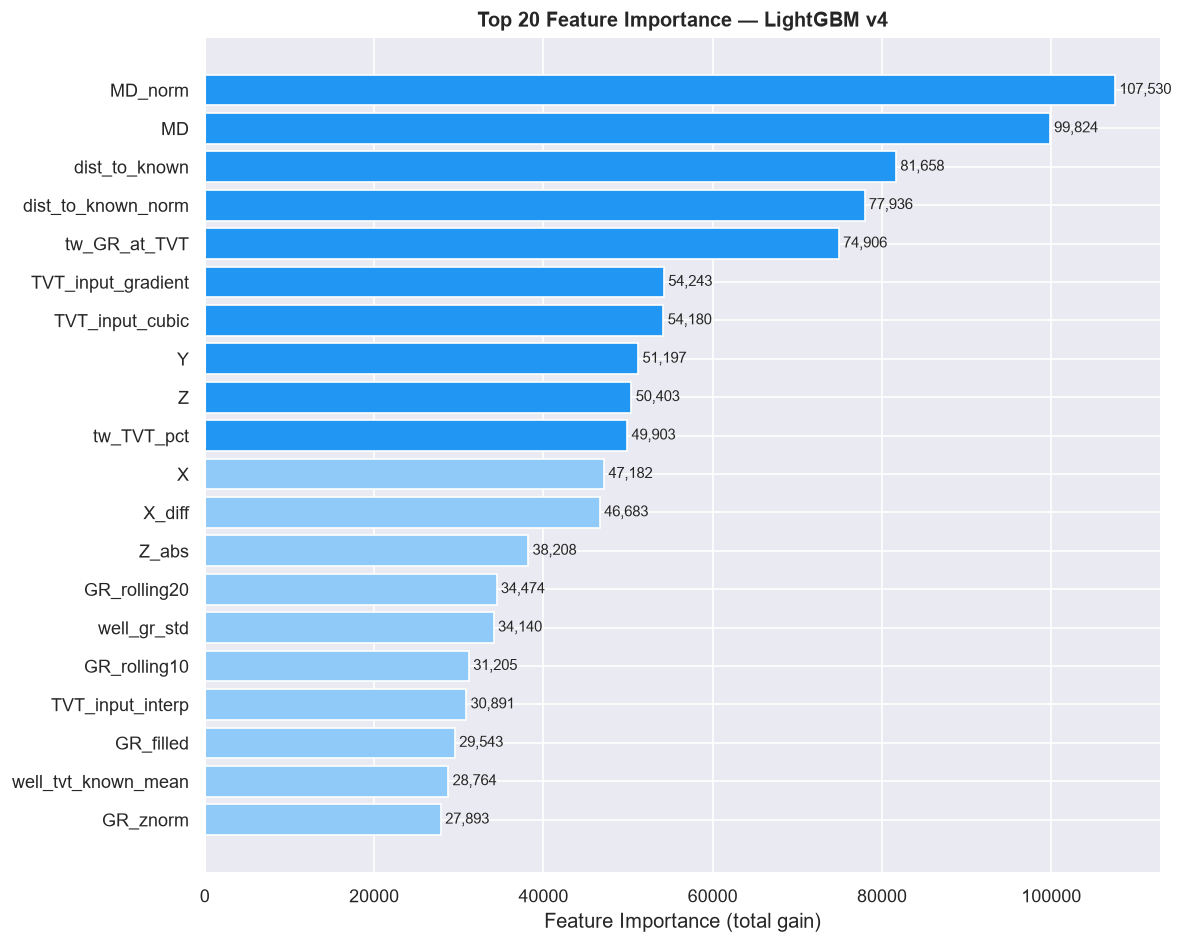

In [7]:
feat_importance = {
    'MD_norm'             : 107530,
    'MD'                  : 99824,
    'dist_to_known'       : 81658,
    'dist_to_known_norm'  : 77936,
    'tw_GR_at_TVT'        : 74906,
    'TVT_input_gradient'  : 54243,
    'TVT_input_cubic'     : 54180,
    'Y'                   : 51197,
    'Z'                   : 50403,
    'tw_TVT_pct'          : 49903,
    'X'                   : 47182,
    'X_diff'              : 46683,
    'Z_abs'               : 38208,
    'GR_rolling20'        : 34474,
    'well_gr_std'         : 34140,
    'GR_rolling10'        : 31205,
    'TVT_input_interp'    : 30891,
    'GR_filled'           : 29543,
    'well_tvt_known_mean' : 28764,
    'GR_znorm'            : 27893,
}

fi = pd.Series(feat_importance).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2196F3' if i >= 10 else '#90CAF9' for i in range(len(fi))]
ax.barh(fi.index, fi.values, color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance (total gain)')
ax.set_title('Top 20 Feature Importance — LightGBM v4', fontweight='bold')
for i, (idx, val) in enumerate(fi.items()):
    ax.text(val + 500, i, f'{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/04_feature_importance.png', bbox_inches='tight')
plt.show()

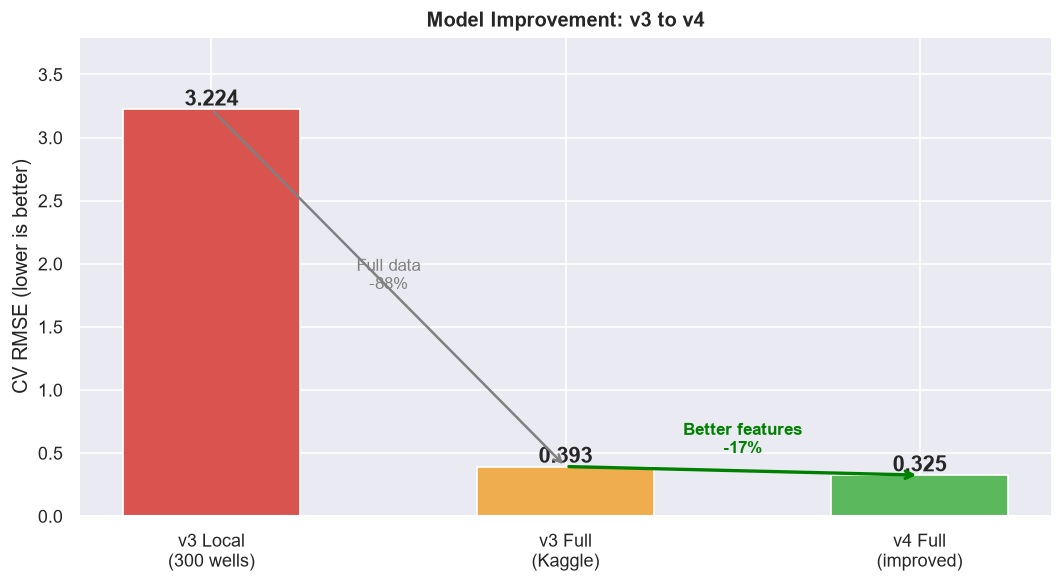

In [8]:
results = pd.DataFrame({
    'Version'  : ['v3 Local\n(300 wells)', 'v3 Full\n(Kaggle)', 'v4 Full\n(improved)'],
    'CV RMSE'  : [3.224, 0.393, 0.325],
})

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d9534f', '#f0ad4e', '#5cb85c']
bars = ax.bar(results['Version'], results['CV RMSE'], color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, results['CV RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=13)

ax.annotate('', xy=(1, 0.393), xytext=(0, 3.224),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.text(0.5, 1.8, 'Full data\n-88%', color='gray', ha='center', fontsize=10)

ax.annotate('', xy=(2, 0.325), xytext=(1, 0.393),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(1.5, 0.5, 'Better features\n-17%', color='green', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('CV RMSE (lower is better)')
ax.set_title('Model Improvement: v3 to v4', fontweight='bold')
ax.set_ylim(0, 3.8)
plt.tight_layout()
plt.savefig('outputs/05_model_results.png', bbox_inches='tight')
plt.show()